<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ROSG Test5C-i6 — Full IFS Reconstruction Compliance / Hyper-Compliance Audit

**Status:** full reconstruction, no provisional \(i=6\), no extrapolation from \(i=5\).

This notebook extends the Test5 V3b reconstruction to:

\[
i=1,2,3,4,5,6.
\]

The level \(i=6\) is reconstructed directly by the same IFS/PCF graph-building rules used for previous Test5 levels:

\[
L_i=2^i,\qquad |V_i|=(L_i+1)^2,\qquad |E_i|=2L_i(L_i+1).
\]

For \(i=6\):

\[
L_6=64,\qquad |V_6|=4225,\qquad |E_6|=8320,\qquad 4^6=4096.
\]

The notebook computes:

\[
V_i,\ E_i,\ c_{xy}^{(i)}(Z),\ m_{\rm eff}^{(i)}(Z),\ L_i(Z),\ \lambda_1^{(i)}(Z),
\]

then:

\[
\lambda_{1,\mathrm{scaled}}^{(i)}(Z)=4^i\lambda_1^{(i)}(Z).
\]

After reconstruction, it performs the Test5C compliance audit:

\[
R_K^{(i)}(Z),\quad \Gamma_{\rm mc}^{(i)}(Z),\quad \hat K_{\rm IFS}(i,Z),\quad \hat\chi_{\rm IFS}(i,Z).
\]

## Reviewer-safe statement

This is a numerical/diagnostic reconstruction. It is not a proof of Mosco convergence, not a DSI detection test, and not a derivation of fundamental gravity. It provides the missing full \(i=6\) input requested before stronger Test6g/Test7 claims.

In [1]:
# ============================================================
# 1. Imports, configuration, directories
# ============================================================

import os, json, math, time, hashlib, shutil, platform, warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy.sparse as sp
    from scipy.sparse.csgraph import connected_components
    from scipy.sparse.linalg import eigsh
    SCIPY_AVAILABLE = True
except Exception as exc:
    SCIPY_AVAILABLE = False
    SCIPY_IMPORT_ERROR = repr(exc)

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)

try:
    from google.colab import drive, files
    IN_COLAB = True
except Exception:
    IN_COLAB = False


@dataclass
class Test5Ci6FullConfig:
    project_name: str = 'ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit'

    # Full reconstruction levels.
    levels_i: tuple = (1, 2, 3, 4, 5, 6)
    calibration_levels_i: tuple = (1, 2)
    stabilization_levels_i: tuple = (3, 4, 5, 6)

    # IFS / conductance model inherited from Test5 V3b.
    lambda_lattice: float = 2.0
    base_conductance: float = 1.0
    vertical_gain: float = 2.1
    activation_center_Z: float = 1.75
    activation_width_Z: float = 0.75
    Z_min: float = -1.0
    Z_max: float = 5.0
    n_Z: int = 17

    # Output / cache.
    use_google_drive: bool = True
    out_dir_drive: str = '/content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit'
    out_dir_local: str = '/content/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit'
    force_recompute: bool = False

    # Sparse eigensolver.
    eigsh_k: int = 6
    eigsh_tol: float = 1e-6
    eigsh_maxiter: int = 30000

    # Compliance audit.
    i_ref: int = 1
    eps: float = 1e-12
    w_c: float = 0.50
    w_lambda: float = 0.50
    gamma_mode: str = 'edge_multiplicity'  # edge_multiplicity or conductive_load

CFG = Test5Ci6FullConfig()


def prepare_output_dir(cfg=CFG):
    if IN_COLAB and cfg.use_google_drive:
        if not Path('/content/drive/MyDrive').exists():
            drive.mount('/content/drive', force_remount=False)
        out = Path(cfg.out_dir_drive)
    else:
        out = Path(cfg.out_dir_local)
    out.mkdir(parents=True, exist_ok=True)
    (out / 'figures').mkdir(parents=True, exist_ok=True)
    return out, out / 'figures'

OUT_DIR, FIG_DIR = prepare_output_dir(CFG)

with open(OUT_DIR / 'test5C_i6_full_config.json', 'w', encoding='utf-8') as f:
    json.dump(asdict(CFG), f, indent=2, ensure_ascii=False)

print('Python:', platform.python_version())
print('SciPy available:', SCIPY_AVAILABLE)
if not SCIPY_AVAILABLE:
    print('SciPy import error:', SCIPY_IMPORT_ERROR)
print('Running in Colab:', IN_COLAB)
print('OUT_DIR:', OUT_DIR)
print('Levels:', CFG.levels_i)

Mounted at /content/drive
Python: 3.12.13
SciPy available: True
Running in Colab: True
OUT_DIR: /content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit
Levels: (1, 2, 3, 4, 5, 6)


## 2. Full Test5 V3b-style reconstruction up to \(i=6\)

This block reconstructs the IFS approximation graphs directly. It does **not** extrapolate \(i=6\) from \(i=5\).

For each \(i\):

\[
V_i=\{(x/L_i,y/L_i):x,y=0,\dots,L_i\},\qquad L_i=2^i.
\]

Edges are horizontal/vertical nearest-neighbor links on the dyadic collage grid, with bounded incidence:

\[
\max_x \deg(x)\leq 4.
\]

In [2]:
# ============================================================
# 2. IFS / PCF graph reconstruction functions
# ============================================================

def level_role(i, cfg=CFG):
    if i in cfg.calibration_levels_i:
        return 'calibration_control'
    if i in cfg.stabilization_levels_i:
        return 'stabilization_numeric'
    return 'auxiliary'


def grid_size_from_i(i):
    return 2 ** int(i)


def exact_counts_for_i(i):
    L = grid_size_from_i(i)
    return {
        'grid_L': int(L),
        'num_points_Vi': int((L + 1) ** 2),
        'num_edges_Ei': int(2 * L * (L + 1)),
        'num_cells': int(4 ** int(i)),
    }


def build_Vi(i):
    L = grid_size_from_i(i)
    pts = []
    for y in range(L + 1):
        for x in range(L + 1):
            pts.append({
                'point_id': y * (L + 1) + x,
                'i': int(i),
                'x_index': int(x),
                'y_index': int(y),
                'x': float(x / L),
                'y': float(y / L),
                'is_boundary': bool(x == 0 or y == 0 or x == L or y == L),
                'role': level_role(i),
            })
    return pd.DataFrame(pts)


def build_Ei(i):
    L = grid_size_from_i(i)
    rows = []
    edge_id = 0

    def node_id(x, y):
        return y * (L + 1) + x

    for y in range(L + 1):
        for x in range(L + 1):
            u = node_id(x, y)
            if x < L:
                rows.append({
                    'edge_id': edge_id,
                    'i': int(i),
                    'u': int(u),
                    'v': int(node_id(x + 1, y)),
                    'orientation': 'horizontal',
                    'role': level_role(i),
                })
                edge_id += 1
            if y < L:
                rows.append({
                    'edge_id': edge_id,
                    'i': int(i),
                    'u': int(u),
                    'v': int(node_id(x, y + 1)),
                    'orientation': 'vertical',
                    'role': level_role(i),
                })
                edge_id += 1
    return pd.DataFrame(rows)


def local_hierarchy_level_for_edge(row, i):
    # Proxy for dyadic hierarchy on an edge midpoint, inherited from Test5 V3/V3b.
    L = grid_size_from_i(i)
    u, v = int(row['u']), int(row['v'])
    ux, uy = u % (L + 1), u // (L + 1)
    vx, vy = v % (L + 1), v // (L + 1)
    mx2 = ux + vx
    my2 = uy + vy

    def tz(a):
        a = int(abs(a))
        if a == 0:
            return int(i)
        c = 0
        while a % 2 == 0 and c < i:
            c += 1
            a //= 2
        return c

    return int(min(i, max(tz(mx2), tz(my2))))


def activation_multiplicity(Z, theta, width):
    return float(1.0 / (1.0 + math.exp(-(float(Z) - float(theta)) / max(float(width), 1e-12))))


def conductance_for_edge(row, Z, cfg=CFG):
    h = local_hierarchy_level_for_edge(row, int(row['i']))
    theta = cfg.activation_center_Z - 0.12 * h
    m = activation_multiplicity(Z, theta, cfg.activation_width_Z)
    c = cfg.base_conductance + cfg.vertical_gain * m
    return m, c, theta, h


def annotate_edges_with_conductance(Ei, Z, cfg=CFG):
    rows = []
    for _, row in Ei.iterrows():
        m, c, theta, h = conductance_for_edge(row, Z, cfg)
        d = dict(row)
        d.update({
            'Z': float(Z),
            'hierarchy_h': int(h),
            'theta_edge': float(theta),
            'm_eff': float(m),
            'c_eff': float(c),
        })
        rows.append(d)
    return pd.DataFrame(rows)


def graph_stats(Vi, Ei):
    n = len(Vi)
    degrees = np.zeros(n, dtype=int)
    for _, e in Ei.iterrows():
        degrees[int(e['u'])] += 1
        degrees[int(e['v'])] += 1

    max_incidence = int(degrees.max()) if len(degrees) else 0

    if SCIPY_AVAILABLE:
        data = np.ones(2 * len(Ei))
        rows = []
        cols = []
        for _, e in Ei.iterrows():
            u, v = int(e['u']), int(e['v'])
            rows += [u, v]
            cols += [v, u]
        A = sp.coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()
        n_components, labels = connected_components(A, directed=False)
        counts = np.bincount(labels)
        lcc_ratio = float(counts.max() / n) if len(counts) else 0.0
    else:
        n_components, lcc_ratio = 1, 1.0

    counts = exact_counts_for_i(int(Vi['i'].iloc[0]))
    return {
        **counts,
        'max_incidence': int(max_incidence),
        'n_components': int(n_components),
        'lcc_ratio': float(lcc_ratio),
    }


def weighted_laplacian_from_edges(n_points, Ec):
    if not SCIPY_AVAILABLE:
        raise RuntimeError('SciPy is required to compute sparse Laplacian eigenvalues.')

    rows, cols, data = [], [], []
    deg = np.zeros(n_points, dtype=float)

    for _, e in Ec.iterrows():
        u, v, c = int(e['u']), int(e['v']), float(e['c_eff'])
        rows += [u, v]
        cols += [v, u]
        data += [-c, -c]
        deg[u] += c
        deg[v] += c

    rows += list(range(n_points))
    cols += list(range(n_points))
    data += list(deg)

    return sp.coo_matrix((data, (rows, cols)), shape=(n_points, n_points)).tocsr()


def lambda1_laplacian(n_points, Ec, cfg=CFG):
    L = weighted_laplacian_from_edges(n_points, Ec)

    try:
        if n_points <= 128:
            vals = np.linalg.eigvalsh(L.toarray())
            vals = np.sort(np.real(vals))
        else:
            k = min(int(cfg.eigsh_k), n_points - 1)
            vals = eigsh(
                L,
                k=k,
                which='SM',
                return_eigenvectors=False,
                tol=float(cfg.eigsh_tol),
                maxiter=int(cfg.eigsh_maxiter),
            )
            vals = np.sort(np.real(vals))

        nz = vals[vals > 1e-9]
        return float(nz[0]) if len(nz) else float('nan')

    except Exception as exc:
        print('[lambda1 warning]', repr(exc))
        return float('nan')


def scale_lambda1(lambda1, i):
    return float(lambda1 * (4 ** int(i)))

In [3]:
# ============================================================
# 3. Checkpoint/cache by level_i and full run to i=6
# ============================================================

def level_dir(i):
    d = OUT_DIR / f'level_i_{int(i)}'
    d.mkdir(parents=True, exist_ok=True)
    return d


def required_level_files(i):
    d = level_dir(i)
    return [
        d / 'ifs_points_Vi.csv',
        d / 'ifs_edges_Ei.csv',
        d / f'level_i_{int(i)}_scan.csv',
        d / f'level_i_{int(i)}_summary.json',
        d / f'level_i_{int(i)}_config.json',
        d / 'COMPLETE.flag',
    ]


def is_level_complete(i):
    return all(p.exists() and p.stat().st_size > 0 for p in required_level_files(i))


def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with Path(path).open('w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def load_json(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return json.load(f)


def compute_level(i, cfg=CFG):
    d = level_dir(i)

    if is_level_complete(i) and not cfg.force_recompute:
        print(f'[cache] level_i={i} already complete; loading.')
        scan = pd.read_csv(d / f'level_i_{int(i)}_scan.csv')
        summary = load_json(d / f'level_i_{int(i)}_summary.json')
        return scan, summary

    print(f'[compute] full reconstruction level_i={i}')
    Vi = build_Vi(i)
    Ei = build_Ei(i)
    stats = graph_stats(Vi, Ei)

    Z_grid = np.linspace(cfg.Z_min, cfg.Z_max, cfg.n_Z)
    scan_rows = []

    t0 = time.time()
    for j, Z in enumerate(Z_grid, start=1):
        print(f'  level_i={i} Z {j}/{len(Z_grid)} = {Z:.4f}')
        Ec = annotate_edges_with_conductance(Ei, Z, cfg)
        lam1 = lambda1_laplacian(len(Vi), Ec, cfg)
        lam1_scaled = scale_lambda1(lam1, i)

        scan_rows.append({
            'i': int(i),
            'role': level_role(i),
            'Z': float(Z),
            **stats,
            'm_eff_mean': float(Ec['m_eff'].mean()),
            'm_eff_std': float(Ec['m_eff'].std(ddof=0)),
            'c_eff_mean': float(Ec['c_eff'].mean()),
            'c_eff_std': float(Ec['c_eff'].std(ddof=0)),
            'lambda1_weighted': float(lam1),
            'lambda1_scaled_4powi': float(lam1_scaled),
            'full_reconstruction': True,
            'provisional_i6': False,
        })

    scan = pd.DataFrame(scan_rows)
    low = scan.head(3).mean(numeric_only=True)
    high = scan.tail(3).mean(numeric_only=True)
    omega0 = float(2.0 * math.pi / math.log(cfg.lambda_lattice))

    summary = {
        'i': int(i),
        'role': level_role(i),
        **stats,
        'Z_min': float(cfg.Z_min),
        'Z_max': float(cfg.Z_max),
        'n_Z': int(cfg.n_Z),
        'm_low_first3_mean': float(low['m_eff_mean']),
        'm_high_last3_mean': float(high['m_eff_mean']),
        'm_gain': float(high['m_eff_mean'] - low['m_eff_mean']),
        'c_low_first3_mean': float(low['c_eff_mean']),
        'c_high_last3_mean': float(high['c_eff_mean']),
        'c_gain': float(high['c_eff_mean'] - low['c_eff_mean']),
        'lambda1_low_first3_mean': float(low['lambda1_weighted']),
        'lambda1_high_last3_mean': float(high['lambda1_weighted']),
        'lambda1_scaled_low_first3_mean': float(low['lambda1_scaled_4powi']),
        'lambda1_scaled_high_last3_mean': float(high['lambda1_scaled_4powi']),
        'lattice_candidate': True,
        'lambda_lattice': float(cfg.lambda_lattice),
        'omega0_for_Test6': omega0,
        'full_reconstruction': True,
        'provisional_i6': False,
        'elapsed_seconds': float(time.time() - t0),
        'status': 'completed',
    }

    Vi.to_csv(d / 'ifs_points_Vi.csv', index=False)
    Ei.to_csv(d / 'ifs_edges_Ei.csv', index=False)
    scan.to_csv(d / f'level_i_{int(i)}_scan.csv', index=False)
    save_json(summary, d / f'level_i_{int(i)}_summary.json')
    save_json(asdict(cfg), d / f'level_i_{int(i)}_config.json')
    (d / 'COMPLETE.flag').write_text(time.strftime('%Y-%m-%d %H:%M:%S'), encoding='utf-8')

    return scan, summary


def run_full_reconstruction(cfg=CFG):
    all_scans = []
    summaries = []

    for i in cfg.levels_i:
        scan_i, summary_i = compute_level(i, cfg)
        all_scans.append(scan_i)
        summaries.append(summary_i)

    cross = pd.DataFrame(summaries).sort_values('i').reset_index(drop=True)
    scan_all = pd.concat(all_scans, ignore_index=True).sort_values(['i', 'Z']).reset_index(drop=True)

    cross.to_csv(OUT_DIR / 'cross_level_comparison_i1_i6_FULL.csv', index=False)
    scan_all.to_csv(OUT_DIR / 'all_levels_scan_i1_i6_FULL.csv', index=False)

    # Compatibility names for Test5C-style downstream scripts.
    cross.to_csv(OUT_DIR / 'cross_level_comparison.csv', index=False)
    scan_all.to_csv(OUT_DIR / 'all_levels_scan.csv', index=False)

    return cross, scan_all


cross, scan_all = run_full_reconstruction(CFG)

print('Full reconstruction completed.')
display(cross)
display(scan_all.head())

[compute] full reconstruction level_i=1
  level_i=1 Z 1/17 = -1.0000
  level_i=1 Z 2/17 = -0.6250
  level_i=1 Z 3/17 = -0.2500
  level_i=1 Z 4/17 = 0.1250
  level_i=1 Z 5/17 = 0.5000
  level_i=1 Z 6/17 = 0.8750
  level_i=1 Z 7/17 = 1.2500
  level_i=1 Z 8/17 = 1.6250
  level_i=1 Z 9/17 = 2.0000
  level_i=1 Z 10/17 = 2.3750
  level_i=1 Z 11/17 = 2.7500
  level_i=1 Z 12/17 = 3.1250
  level_i=1 Z 13/17 = 3.5000
  level_i=1 Z 14/17 = 3.8750
  level_i=1 Z 15/17 = 4.2500
  level_i=1 Z 16/17 = 4.6250
  level_i=1 Z 17/17 = 5.0000
[compute] full reconstruction level_i=2
  level_i=2 Z 1/17 = -1.0000
  level_i=2 Z 2/17 = -0.6250
  level_i=2 Z 3/17 = -0.2500
  level_i=2 Z 4/17 = 0.1250
  level_i=2 Z 5/17 = 0.5000
  level_i=2 Z 6/17 = 0.8750
  level_i=2 Z 7/17 = 1.2500
  level_i=2 Z 8/17 = 1.6250
  level_i=2 Z 9/17 = 2.0000
  level_i=2 Z 10/17 = 2.3750
  level_i=2 Z 11/17 = 2.7500
  level_i=2 Z 12/17 = 3.1250
  level_i=2 Z 13/17 = 3.5000
  level_i=2 Z 14/17 = 3.8750
  level_i=2 Z 15/17 = 4.2500
  le

,i,role,grid_L,num_points_Vi,num_edges_Ei,num_cells,max_incidence,n_components,lcc_ratio,Z_min,...,lambda1_high_last3_mean,lambda1_scaled_low_first3_mean,lambda1_scaled_high_last3_mean,lattice_candidate,lambda_lattice,omega0_for_Test6,full_reconstruction,provisional_i6,elapsed_seconds,status
0,1,calibration_control,2,9,12,4,4,1,1.0,-1.0,...,3.058933,4.424594,12.235734,True,2.0,9.06472,True,False,0.209944,completed
1,2,calibration_control,4,25,40,16,4,1,1.0,-1.0,...,1.169773,6.823136,18.716372,True,2.0,9.06472,True,False,0.323502,completed
2,3,stabilization_numeric,8,81,144,64,4,1,1.0,-1.0,...,0.369557,8.663110,23.651634,True,2.0,9.06472,True,False,0.638464,completed
3,4,stabilization_numeric,16,289,544,256,4,1,1.0,-1.0,...,0.104353,9.807735,26.714390,True,2.0,9.06472,True,False,1.908504,completed
4,5,stabilization_numeric,32,1089,2112,1024,4,1,1.0,-1.0,...,0.027752,10.443310,28.417691,True,2.0,9.06472,True,False,6.769083,completed
5,6,stabilization_numeric,64,4225,8320,4096,4,1,1.0,-1.0,...,0.007157,10.776507,29.314635,True,2.0,9.06472,True,False,19.975817,completed


,i,role,Z,grid_L,num_points_Vi,num_edges_Ei,num_cells,max_incidence,n_components,lcc_ratio,m_eff_mean,m_eff_std,c_eff_mean,c_eff_std,lambda1_weighted,lambda1_scaled_4powi,full_reconstruction,provisional_i6
0,1,calibration_control,-1.000,2,9,12,4,4,1,1.0,0.029123,1.040834e-17,1.061159,2.220446e-16,1.061159,4.244634,True,False
1,1,calibration_control,-0.625,2,9,12,4,4,1,1.0,0.047126,6.938894e-18,1.098964,0.000000e+00,1.098964,4.395855,True,False
2,1,calibration_control,-0.250,2,9,12,4,4,1,1.0,0.075392,1.387779e-17,1.158323,0.000000e+00,1.158323,4.633294,True,False
3,1,calibration_control,0.125,2,9,12,4,4,1,1.0,0.118505,1.387779e-17,1.248860,2.220446e-16,1.248860,4.995440,True,False
4,1,calibration_control,0.500,2,9,12,4,4,1,1.0,0.181433,0.000000e+00,1.381010,2.220446e-16,1.381010,5.524040,True,False


## 4. Compliance / hyper-compliance audit derived from full \(i=1,\dots,6\) reconstruction

The compliance audit is now computed from the fully reconstructed scan, including \(i=6\).

No \(i=6\) extrapolation is used.

In [4]:
# ============================================================
# 4. Compute Test5C compliance profiles from reconstructed i=1..6 data
# ============================================================

df = scan_all.copy()
df = df.sort_values(['i', 'Z']).reset_index(drop=True)

required = ['i', 'Z', 'num_edges_Ei', 'm_eff_mean', 'c_eff_mean', 'lambda1_scaled_4powi']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns for Test5C compliance: {missing}')

ref = df[df['i'].astype(int) == int(CFG.i_ref)].copy()
if ref.empty:
    raise ValueError(f'Reference level i_ref={CFG.i_ref} not found.')

ref_cols = ref[['Z', 'c_eff_mean', 'lambda1_scaled_4powi', 'num_edges_Ei', 'm_eff_mean']].rename(columns={
    'c_eff_mean': 'c_eff_ref',
    'lambda1_scaled_4powi': 'lambda1_scaled_ref',
    'num_edges_Ei': 'num_edges_ref',
    'm_eff_mean': 'm_eff_ref',
})

df = df.merge(ref_cols, on='Z', how='left', validate='many_to_one')

eps = float(CFG.eps)

df['R_c_iZ'] = df['c_eff_mean'] / np.maximum(df['c_eff_ref'], eps)
df['R_lambda_iZ'] = df['lambda1_scaled_4powi'] / np.maximum(df['lambda1_scaled_ref'], eps)

df['log_R_K_iZ'] = (
    float(CFG.w_c) * np.log(np.maximum(df['R_c_iZ'], eps))
    + float(CFG.w_lambda) * np.log(np.maximum(df['R_lambda_iZ'], eps))
)
df['R_K_iZ'] = np.exp(df['log_R_K_iZ'])

df['A_mc_edge_multiplicity_iZ'] = df['num_edges_Ei'] * df['m_eff_mean']
df['A_mc_edge_multiplicity_ref'] = df['num_edges_ref'] * df['m_eff_ref']

df['A_mc_conductive_load_iZ'] = df['num_edges_Ei'] * df['m_eff_mean'] * df['c_eff_mean']
df['A_mc_conductive_load_ref'] = df['num_edges_ref'] * df['m_eff_ref'] * df['c_eff_ref']

if CFG.gamma_mode == 'edge_multiplicity':
    df['Gamma_mc_iZ'] = df['A_mc_edge_multiplicity_iZ'] / np.maximum(df['A_mc_edge_multiplicity_ref'], eps)
elif CFG.gamma_mode == 'conductive_load':
    df['Gamma_mc_iZ'] = df['A_mc_conductive_load_iZ'] / np.maximum(df['A_mc_conductive_load_ref'], eps)
else:
    raise ValueError(f'Unknown gamma_mode: {CFG.gamma_mode}')

df['K_hat_IFS_iZ'] = df['R_K_iZ'] / np.maximum(df['Gamma_mc_iZ'], eps)
df['chi_hat_IFS_iZ'] = df['Gamma_mc_iZ'] / np.maximum(df['R_K_iZ'], eps)
df['duality_check'] = df['K_hat_IFS_iZ'] * df['chi_hat_IFS_iZ']
df['duality_abs_error'] = np.abs(df['duality_check'] - 1.0)

for col in ['R_c_iZ', 'R_lambda_iZ', 'R_K_iZ', 'Gamma_mc_iZ', 'K_hat_IFS_iZ', 'chi_hat_IFS_iZ']:
    df['log_' + col] = np.log(np.maximum(df[col], eps))

df.to_csv(OUT_DIR / 'test5C_i6_FULL_IFS_compliance_profiles.csv', index=False)

display(df.head())
print('Saved:', OUT_DIR / 'test5C_i6_FULL_IFS_compliance_profiles.csv')

,i,role,Z,grid_L,num_points_Vi,num_edges_Ei,num_cells,max_incidence,n_components,lcc_ratio,...,Gamma_mc_iZ,K_hat_IFS_iZ,chi_hat_IFS_iZ,duality_check,duality_abs_error,log_R_c_iZ,log_R_lambda_iZ,log_Gamma_mc_iZ,log_K_hat_IFS_iZ,log_chi_hat_IFS_iZ
0,1,calibration_control,-1.000,2,9,12,4,4,1,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,calibration_control,-0.625,2,9,12,4,4,1,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,calibration_control,-0.250,2,9,12,4,4,1,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,calibration_control,0.125,2,9,12,4,4,1,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,calibration_control,0.500,2,9,12,4,4,1,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved: /content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit/test5C_i6_FULL_IFS_compliance_profiles.csv


In [5]:
# ============================================================
# 5. Summary and stabilization metrics
# ============================================================

def z_at_max(g, value_col):
    idx = g[value_col].idxmax()
    return float(g.loc[idx, 'Z'])


def z_at_min(g, value_col):
    idx = g[value_col].idxmin()
    return float(g.loc[idx, 'Z'])

summary_rows = []
for i, g in df.groupby('i'):
    summary_rows.append({
        'i': int(i),
        'role': str(g['role'].iloc[0]) if 'role' in g.columns else level_role(i),
        'n_Z': int(len(g)),
        'num_points_Vi': int(g['num_points_Vi'].iloc[0]),
        'num_edges_Ei': int(g['num_edges_Ei'].iloc[0]),
        'num_cells': int(g['num_cells'].iloc[0]),
        'grid_L': int(g['grid_L'].iloc[0]),
        'R_c_mean': float(g['R_c_iZ'].mean()),
        'R_lambda_mean': float(g['R_lambda_iZ'].mean()),
        'R_K_mean': float(g['R_K_iZ'].mean()),
        'R_K_min': float(g['R_K_iZ'].min()),
        'R_K_max': float(g['R_K_iZ'].max()),
        'Gamma_mc_mean': float(g['Gamma_mc_iZ'].mean()),
        'Gamma_mc_min': float(g['Gamma_mc_iZ'].min()),
        'Gamma_mc_max': float(g['Gamma_mc_iZ'].max()),
        'K_hat_mean': float(g['K_hat_IFS_iZ'].mean()),
        'K_hat_min': float(g['K_hat_IFS_iZ'].min()),
        'K_hat_max': float(g['K_hat_IFS_iZ'].max()),
        'chi_hat_mean': float(g['chi_hat_IFS_iZ'].mean()),
        'chi_hat_min': float(g['chi_hat_IFS_iZ'].min()),
        'chi_hat_max': float(g['chi_hat_IFS_iZ'].max()),
        'Z_at_chi_max': z_at_max(g, 'chi_hat_IFS_iZ'),
        'Z_at_K_min': z_at_min(g, 'K_hat_IFS_iZ'),
        'duality_error_max': float(g['duality_abs_error'].max()),
        'full_reconstruction': bool(g['full_reconstruction'].all()) if 'full_reconstruction' in g.columns else True,
        'provisional_i6': bool(g['provisional_i6'].any()) if 'provisional_i6' in g.columns else False,
    })

summary = pd.DataFrame(summary_rows).sort_values('i').reset_index(drop=True)
summary['hyper_compliance_flag'] = (
    (summary['i'] > CFG.i_ref)
    & (summary['chi_hat_mean'] > 1.0)
    & (summary['K_hat_mean'] < 1.0)
)

summary.to_csv(OUT_DIR / 'test5C_i6_FULL_IFS_compliance_summary.csv', index=False)

stab = summary[summary['i'].isin(CFG.stabilization_levels_i)].copy()
stab_metrics = {
    'levels_used_for_stabilization': list(map(int, CFG.stabilization_levels_i)),
    'levels_used_for_calibration': list(map(int, CFG.calibration_levels_i)),
    'gamma_mode': CFG.gamma_mode,
    'w_c': CFG.w_c,
    'w_lambda': CFG.w_lambda,
    'includes_full_i6': bool(6 in summary['i'].astype(int).tolist()),
    'i6_is_provisional': bool(summary.loc[summary['i'] == 6, 'provisional_i6'].any()) if 6 in summary['i'].tolist() else None,
    'status': 'completed',
}

for col in ['R_K_mean', 'Gamma_mc_mean', 'K_hat_mean', 'chi_hat_mean']:
    vals = stab[col].to_numpy(dtype=float)
    stab_metrics[col + '_mean_stabilization'] = float(np.nanmean(vals))
    stab_metrics[col + '_std_stabilization'] = float(np.nanstd(vals))
    stab_metrics[col + '_rel_std_stabilization'] = float(np.nanstd(vals) / max(abs(np.nanmean(vals)), eps))

s5 = summary[summary['i'] == 5].iloc[0].to_dict()
s6 = summary[summary['i'] == 6].iloc[0].to_dict()
for col in ['R_K_mean', 'Gamma_mc_mean', 'K_hat_mean', 'chi_hat_mean']:
    stab_metrics[f'{col}_i5'] = float(s5[col])
    stab_metrics[f'{col}_i6'] = float(s6[col])
    stab_metrics[f'{col}_i6_over_i5'] = float(s6[col] / max(abs(s5[col]), eps))

pd.DataFrame([stab_metrics]).to_csv(
    OUT_DIR / 'test5C_i6_FULL_IFS_compliance_stabilization_metrics.csv',
    index=False
)

print('Summary:')
display(summary)

print('Stabilization metrics:')
display(pd.DataFrame([stab_metrics]))

Summary:


,i,role,n_Z,num_points_Vi,num_edges_Ei,num_cells,grid_L,R_c_mean,R_lambda_mean,R_K_mean,...,K_hat_max,chi_hat_mean,chi_hat_min,chi_hat_max,Z_at_chi_max,Z_at_K_min,duality_error_max,full_reconstruction,provisional_i6,hyper_compliance_flag
0,1,calibration_control,17,9,12,4,2,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,-1.0,-1.0,0.000000e+00,True,False,False
1,2,calibration_control,17,25,40,16,4,1.012341,1.546690,1.251311,...,0.370702,2.781606,2.697584,2.950824,-1.0,-1.0,1.110223e-16,True,False,True
2,3,stabilization_numeric,17,81,144,64,8,1.018452,1.965388,1.414798,...,0.115714,9.053199,8.642017,9.912496,-1.0,-1.0,2.220446e-16,True,False,True
3,4,stabilization_numeric,17,289,544,256,16,1.020894,2.224934,1.507124,...,0.032550,32.408470,30.722385,36.025516,-1.0,-1.0,2.220446e-16,True,False,True
4,5,stabilization_numeric,17,1089,2112,1024,32,1.021616,2.368465,1.555526,...,0.008647,122.302602,115.646418,136.835411,-1.0,-1.0,2.220446e-16,True,False,True
5,6,stabilization_numeric,17,4225,8320,4096,64,1.021676,2.443428,1.579997,...,0.002229,474.662681,448.545813,532.325957,-1.0,-1.0,2.220446e-16,True,False,True


Stabilization metrics:


,levels_used_for_stabilization,levels_used_for_calibration,gamma_mode,w_c,w_lambda,includes_full_i6,i6_is_provisional,status,R_K_mean_mean_stabilization,R_K_mean_std_stabilization,...,R_K_mean_i6_over_i5,Gamma_mc_mean_i5,Gamma_mc_mean_i6,Gamma_mc_mean_i6_over_i5,K_hat_mean_i5,K_hat_mean_i6,K_hat_mean_i6_over_i5,chi_hat_mean_i5,chi_hat_mean_i6,chi_hat_mean_i6_over_i5
0,"[3, 4, 5, 6]","[1, 2]",edge_multiplicity,0.5,0.5,True,False,completed,1.514361,0.063182,...,1.015732,190.307757,750.221879,3.942151,0.008206,0.002114,0.257692,122.302602,474.662681,3.881051


In [6]:
# ============================================================
# 6. Autotests
# ============================================================

def run_autotests(cross, scan_all, df, summary, cfg=CFG):
    print('Running Test5C-i6 FULL reconstruction autotests...')

    assert SCIPY_AVAILABLE, 'SciPy must be available for full sparse Laplacian reconstruction.'

    got_levels = set(map(int, summary['i'].tolist()))
    expected_levels = set(map(int, cfg.levels_i))
    assert got_levels == expected_levels, f'Level mismatch: got {got_levels}, expected {expected_levels}'
    assert 6 in got_levels, 'Full i=6 level missing.'

    i6_summary = summary[summary['i'] == 6].iloc[0]
    assert int(i6_summary['grid_L']) == 64
    assert int(i6_summary['num_points_Vi']) == 4225
    assert int(i6_summary['num_edges_Ei']) == 8320
    assert int(i6_summary['num_cells']) == 4096
    assert bool(i6_summary['full_reconstruction']) is True
    assert bool(i6_summary['provisional_i6']) is False

    for _, row in cross.iterrows():
        assert int(row['max_incidence']) <= 4
        assert int(row['n_components']) == 1
        assert abs(float(row['lcc_ratio']) - 1.0) < 1e-12

    for i, g in scan_all.groupby('i'):
        assert len(g) == int(cfg.n_Z), f'Wrong n_Z at i={i}'

    assert np.all(np.isfinite(scan_all['lambda1_weighted'])), 'lambda1_weighted contains non-finite values.'
    assert np.all(np.isfinite(scan_all['lambda1_scaled_4powi'])), 'lambda1_scaled_4powi contains non-finite values.'
    assert np.all(scan_all['lambda1_weighted'] > 0), 'lambda1_weighted must be positive.'

    for col in ['R_c_iZ', 'R_lambda_iZ', 'R_K_iZ', 'Gamma_mc_iZ', 'K_hat_IFS_iZ', 'chi_hat_IFS_iZ']:
        assert np.all(np.isfinite(df[col])), f'{col} contains non-finite values.'
        assert np.all(df[col] > 0), f'{col} must be positive.'

    max_duality_error = float(df['duality_abs_error'].max())
    assert max_duality_error < 1e-10, f'Duality error too large: {max_duality_error}'

    ref = df[df['i'].astype(int) == int(cfg.i_ref)]
    for col in ['R_c_iZ', 'R_lambda_iZ', 'R_K_iZ', 'Gamma_mc_iZ', 'K_hat_IFS_iZ', 'chi_hat_IFS_iZ']:
        err = float(np.max(np.abs(ref[col].to_numpy(dtype=float) - 1.0)))
        assert err < 1e-10, f'Reference normalization failed for {col}: {err}'

    print('All Test5C-i6 FULL reconstruction autotests passed.')
    print('Max duality error:', max_duality_error)

run_autotests(cross, scan_all, df, summary, CFG)

Running Test5C-i6 FULL reconstruction autotests...
All Test5C-i6 FULL reconstruction autotests passed.
Max duality error: 2.220446049250313e-16


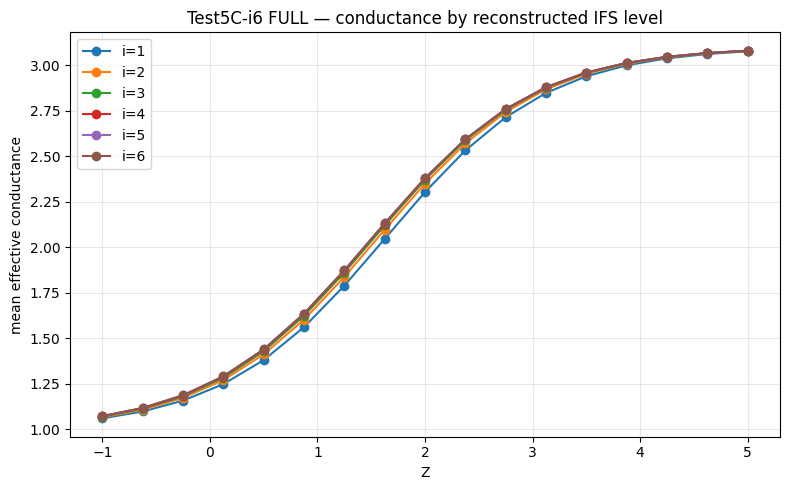

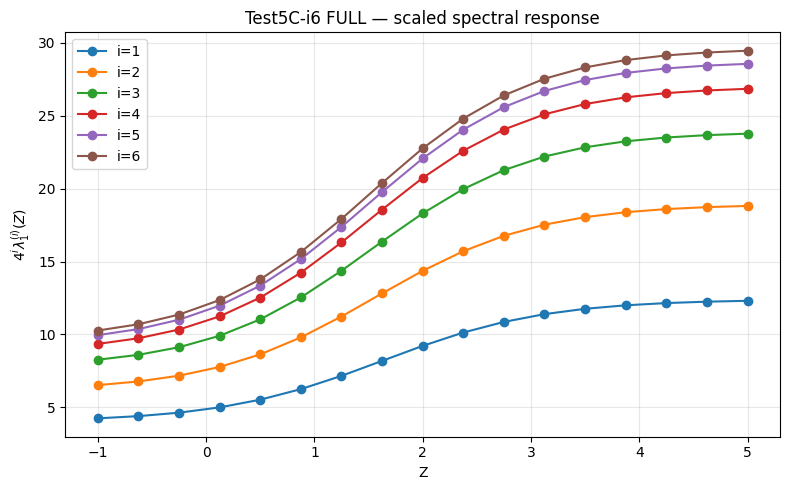

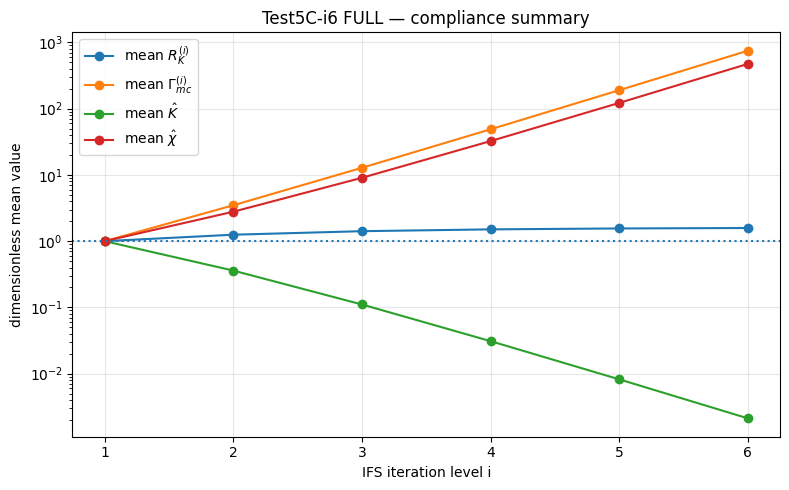

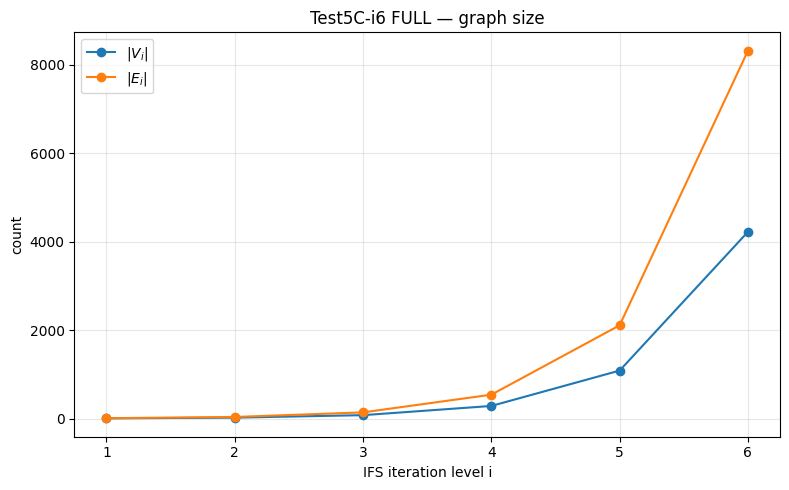

In [7]:
# ============================================================
# 7. Figures
# ============================================================

plt.figure(figsize=(8, 5))
for i, g in scan_all.groupby('i'):
    plt.plot(g['Z'], g['c_eff_mean'], marker='o', label=f'i={int(i)}')
plt.xlabel('Z')
plt.ylabel('mean effective conductance')
plt.title('Test5C-i6 FULL — conductance by reconstructed IFS level')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '01_conductance_by_level_i1_i6_FULL.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
for i, g in scan_all.groupby('i'):
    plt.plot(g['Z'], g['lambda1_scaled_4powi'], marker='o', label=f'i={int(i)}')
plt.xlabel('Z')
plt.ylabel(r'$4^i\lambda_1^{(i)}(Z)$')
plt.title('Test5C-i6 FULL — scaled spectral response')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '02_lambda1_scaled_by_level_i1_i6_FULL.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(summary['i'], summary['R_K_mean'], marker='o', label=r'mean $R_K^{(i)}$')
plt.semilogy(summary['i'], summary['Gamma_mc_mean'], marker='o', label=r'mean $\Gamma_{mc}^{(i)}$')
plt.semilogy(summary['i'], summary['K_hat_mean'], marker='o', label=r'mean $\hat K$')
plt.semilogy(summary['i'], summary['chi_hat_mean'], marker='o', label=r'mean $\hat\chi$')
plt.axhline(1.0, linestyle=':')
plt.xlabel('IFS iteration level i')
plt.ylabel('dimensionless mean value')
plt.title('Test5C-i6 FULL — compliance summary')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '03_compliance_summary_i1_i6_FULL.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(cross['i'], cross['num_points_Vi'], marker='o', label=r'$|V_i|$')
plt.plot(cross['i'], cross['num_edges_Ei'], marker='o', label=r'$|E_i|$')
plt.xlabel('IFS iteration level i')
plt.ylabel('count')
plt.title('Test5C-i6 FULL — graph size')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '04_graph_size_i1_i6_FULL.png', dpi=160)
plt.show()

In [8]:
# ============================================================
# 8. Report, README, manifest, ZIP
# ============================================================

report = {
    'status': 'completed',
    'project': CFG.project_name,
    'full_reconstruction': True,
    'provisional_i6': False,
    'purpose': 'Full Test5 V3b-style reconstruction through i=6, followed by Test5C compliance/hyper-compliance audit.',
    'levels_i': list(map(int, CFG.levels_i)),
    'i6_exact_counts': exact_counts_for_i(6),
    'definitions': {
        'lambda1_scaled_4powi': '4**i * lambda1_weighted',
        'R_c_iZ': 'c_eff_mean(i,Z)/c_eff_mean(i_ref,Z)',
        'R_lambda_iZ': 'lambda1_scaled_4powi(i,Z)/lambda1_scaled_4powi(i_ref,Z)',
        'R_K_iZ': 'geometric weighted mean of R_c_iZ and R_lambda_iZ',
        'Gamma_mc_iZ': 'relative micro-contact load, mode=' + CFG.gamma_mode,
        'K_hat_IFS_iZ': 'R_K_iZ/Gamma_mc_iZ',
        'chi_hat_IFS_iZ': 'Gamma_mc_iZ/R_K_iZ',
    },
    'reviewer_safe_status': [
        'i=6 is reconstructed directly, not extrapolated from i=5.',
        'This is not a DSI detection test.',
        'This is not a proof of Mosco or strong-resolvent convergence.',
        'No internal m/J or J/m interpretation is used.',
        'The output is a numerical audit for Test6g/Test7 and future Mosco pre-audit work.'
    ],
    'configuration': asdict(CFG),
    'summary_by_level': summary.to_dict(orient='records'),
    'stabilization_metrics': stab_metrics,
    'created_time': pd.Timestamp.utcnow().isoformat(),
}

save_json(report, OUT_DIR / 'test5C_i6_FULL_IFS_compliance_report.json')

readme = f"""# ROSG Test5C-i6 FULL Reconstruction — IFS Compliance / Hyper-Compliance Audit

This archive contains a full Test5 V3b-style reconstruction through i=6, followed by Test5C compliance diagnostics.

## Key point

i=6 is reconstructed directly:
- L_6 = 64
- |V_6| = 4225
- |E_6| = 8320
- cells = 4096

No provisional i=6 and no extrapolation from i=5 are used.

## Main outputs

- all_levels_scan_i1_i6_FULL.csv
- cross_level_comparison_i1_i6_FULL.csv
- test5C_i6_FULL_IFS_compliance_profiles.csv
- test5C_i6_FULL_IFS_compliance_summary.csv
- test5C_i6_FULL_IFS_compliance_stabilization_metrics.csv
- test5C_i6_FULL_IFS_compliance_report.json
- figures/
- manifest_sha256.csv

## Reviewer-safe status

This is a numerical audit, not a proof of Mosco convergence, not a DSI detection test, and not a derivation of fundamental gravity.

Generated: {pd.Timestamp.utcnow().isoformat()}
"""

(OUT_DIR / 'README.md').write_text(readme, encoding='utf-8')


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

manifest_rows = []
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file() and p.name != 'manifest_sha256.csv':
        manifest_rows.append({
            'path': str(p.relative_to(OUT_DIR)),
            'size_bytes': int(p.stat().st_size),
            'sha256': sha256_file(p),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(OUT_DIR / 'manifest_sha256.csv', index=False)

zip_path = shutil.make_archive(str(OUT_DIR), 'zip', OUT_DIR)

print('Report:', OUT_DIR / 'test5C_i6_FULL_IFS_compliance_report.json')
print('Manifest:', OUT_DIR / 'manifest_sha256.csv')
print('ZIP:', zip_path)

if IN_COLAB:
    print('Outputs stored in Google Drive when use_google_drive=True.')

Report: /content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit/test5C_i6_FULL_IFS_compliance_report.json
Manifest: /content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit/manifest_sha256.csv
ZIP: /content/drive/MyDrive/ROSG_exports/ROSG_Test5C_i6_FULL_RECONSTRUCTION_IFS_compliance_audit.zip
Outputs stored in Google Drive when use_google_drive=True.


## 9. Interpretation for ROSG

This notebook should be cited as the **full reconstruction** version of Test5C-i6.

Recommended wording:

> Test5C-i6 extends the IFS/PCF reconstruction to the level \(i=6\) without extrapolating from \(i=5\). The level \(i=6\) is built directly from the dyadic graph \(V_6,E_6\), with \(L_6=64\), \(|V_6|=4225\), and \(|E_6|=8320\). The weighted Laplacian and the scaled spectral diagnostic \(4^6\lambda_1^{(6)}\) are computed from the reconstructed conductance graph. This provides the missing independent level required to test whether the compliance-weighted broadening observed in Test6g persists beyond the \(i=3,4,5\) stabilization window.